## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Bibliotecas importadas com sucesso.')

Bibliotecas importadas com sucesso.


## 2. Carregar Dataset Limpo

In [2]:
df = pd.read_csv('urldata_clean.csv')

print(f'Linhas  : {df.shape[0]:,}')
print(f'Colunas : {df.shape[1]}')

Linhas  : 95,911
Colunas : 14


In [3]:
df.head()

,domain,ranking,mld_res,mld.ps_res,card_rem,ratio_Rrem,ratio_Arem,jaccard_RR,jaccard_RA,jaccard_AR,jaccard_AA,jaccard_ARrd,jaccard_ARrem,label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,10000000,1,0,12,107.611111,107.277778,0.0,0.0,0.0,0.0,0.8,0.795729,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,10000000,0,0,11,150.636364,152.272727,0.0,0.0,0.0,0.0,0.0,0.768577,1
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,10000000,0,0,12,73.500000,72.642857,0.0,0.0,0.0,0.0,0.0,0.726582,1
3,mail.printakid.com/www.online.americanexpress....,10000000,0,0,6,370.857143,386.232142,0.0,0.0,0.0,0.0,0.0,0.859640,1
4,thewhiskeydregs.com/wp-content/themes/widescre...,10000000,0,0,8,29.000000,24.125000,0.0,0.0,0.0,0.0,0.0,0.748971,1


## 3. Análise das Escalas Actuais

In [4]:
colunas_numericas = ['mld_res', 'mld.ps_res', 'card_rem',
                     'ratio_Rrem', 'ratio_Arem',
                     'jaccard_RR', 'jaccard_RA', 'jaccard_AR',
                     'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem']

print(f'  {"Coluna":<18}  {"Min":>8}  {"Max":>10}  {"Precisa normalizar?":>20}')
print('  ' + '-' * 64)
for col in colunas_numericas:
    mn, mx = df[col].min(), df[col].max()
    precisa = 'NAO' if mn >= 0 and mx <= 1 else 'SIM  <---'
    print(f'  {col:<18}  {mn:>8.3f}  {mx:>10.3f}  {precisa:>20}')

  Coluna                   Min         Max   Precisa normalizar?
  ----------------------------------------------------------------
  mld_res                0.000       1.000                   NAO
  mld.ps_res             0.000       1.000                   NAO
  card_rem               0.000      12.000             SIM  <---
  ratio_Rrem             0.000     370.857             SIM  <---
  ratio_Arem             0.000     386.232             SIM  <---
  jaccard_RR             0.000       1.000                   NAO
  jaccard_RA             0.000       0.917                   NAO
  jaccard_AR             0.000       1.000                   NAO
  jaccard_AA             0.000       1.000                   NAO
  jaccard_ARrd           0.000       1.000                   NAO
  jaccard_ARrem          0.000       0.968                   NAO


In [5]:
# Colunas que necessitam de normalização
colunas_normalizar = ['card_rem', 'ratio_Rrem', 'ratio_Arem']

# Colunas que JÁ estão em [0, 1] — não necessitam de transformação
colunas_ja_norm = ['mld_res', 'mld.ps_res',
                   'jaccard_RR', 'jaccard_RA', 'jaccard_AR',
                   'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem']

print('Colunas a normalizar :', colunas_normalizar)
print('Colunas ja em [0,1]  :', colunas_ja_norm)

Colunas a normalizar : ['card_rem', 'ratio_Rrem', 'ratio_Arem']
Colunas ja em [0,1]  : ['mld_res', 'mld.ps_res', 'jaccard_RR', 'jaccard_RA', 'jaccard_AR', 'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem']


## 4. Aplicação do Min-Max Scaler

In [6]:
df_norm = df.copy()

scaler = MinMaxScaler()
df_norm[colunas_normalizar] = scaler.fit_transform(df[colunas_normalizar])

print(f'  {"Coluna":<15}  {"Min antes":>10}  {"Max antes":>10}  {"Min depois":>11}  {"Max depois":>11}')
print('  ' + '-' * 65)
for col in colunas_normalizar:
    print(f'  {col:<15}'
          f'  {df[col].min():>10.3f}'
          f'  {df[col].max():>10.3f}'
          f'  {df_norm[col].min():>11.3f}'
          f'  {df_norm[col].max():>11.3f}')

print('\nNormalizacao aplicada com sucesso.')

  Coluna            Min antes   Max antes   Min depois   Max depois
  -----------------------------------------------------------------
  card_rem              0.000      12.000        0.000        1.000
  ratio_Rrem            0.000     370.857        0.000        1.000
  ratio_Arem            0.000     386.232        0.000        1.000

Normalizacao aplicada com sucesso.


## 5. Verificação

In [7]:
print(f'  {"Coluna":<18}  {"Min":>8}  {"Max":>10}  {"Em [0,1]?":>12}')
print('  ' + '-' * 54)
for col in colunas_numericas:
    mn = df_norm[col].min()
    mx = df_norm[col].max()
    ok = 'OK' if mn >= 0 and mx <= 1 else 'ERRO'
    print(f'  {col:<18}  {mn:>8.4f}  {mx:>10.4f}  {ok:>12}')

  Coluna                   Min         Max     Em [0,1]?
  ------------------------------------------------------
  mld_res               0.0000      1.0000            OK
  mld.ps_res            0.0000      1.0000            OK
  card_rem              0.0000      1.0000            OK
  ratio_Rrem            0.0000      1.0000            OK
  ratio_Arem            0.0000      1.0000            OK
  jaccard_RR            0.0000      1.0000            OK
  jaccard_RA            0.0000      0.9167            OK
  jaccard_AR            0.0000      1.0000            OK
  jaccard_AA            0.0000      1.0000            OK
  jaccard_ARrd          0.0000      1.0000            OK
  jaccard_ARrem         0.0000      0.9679            OK


## 6. Comparação Visual — Antes vs. Depois

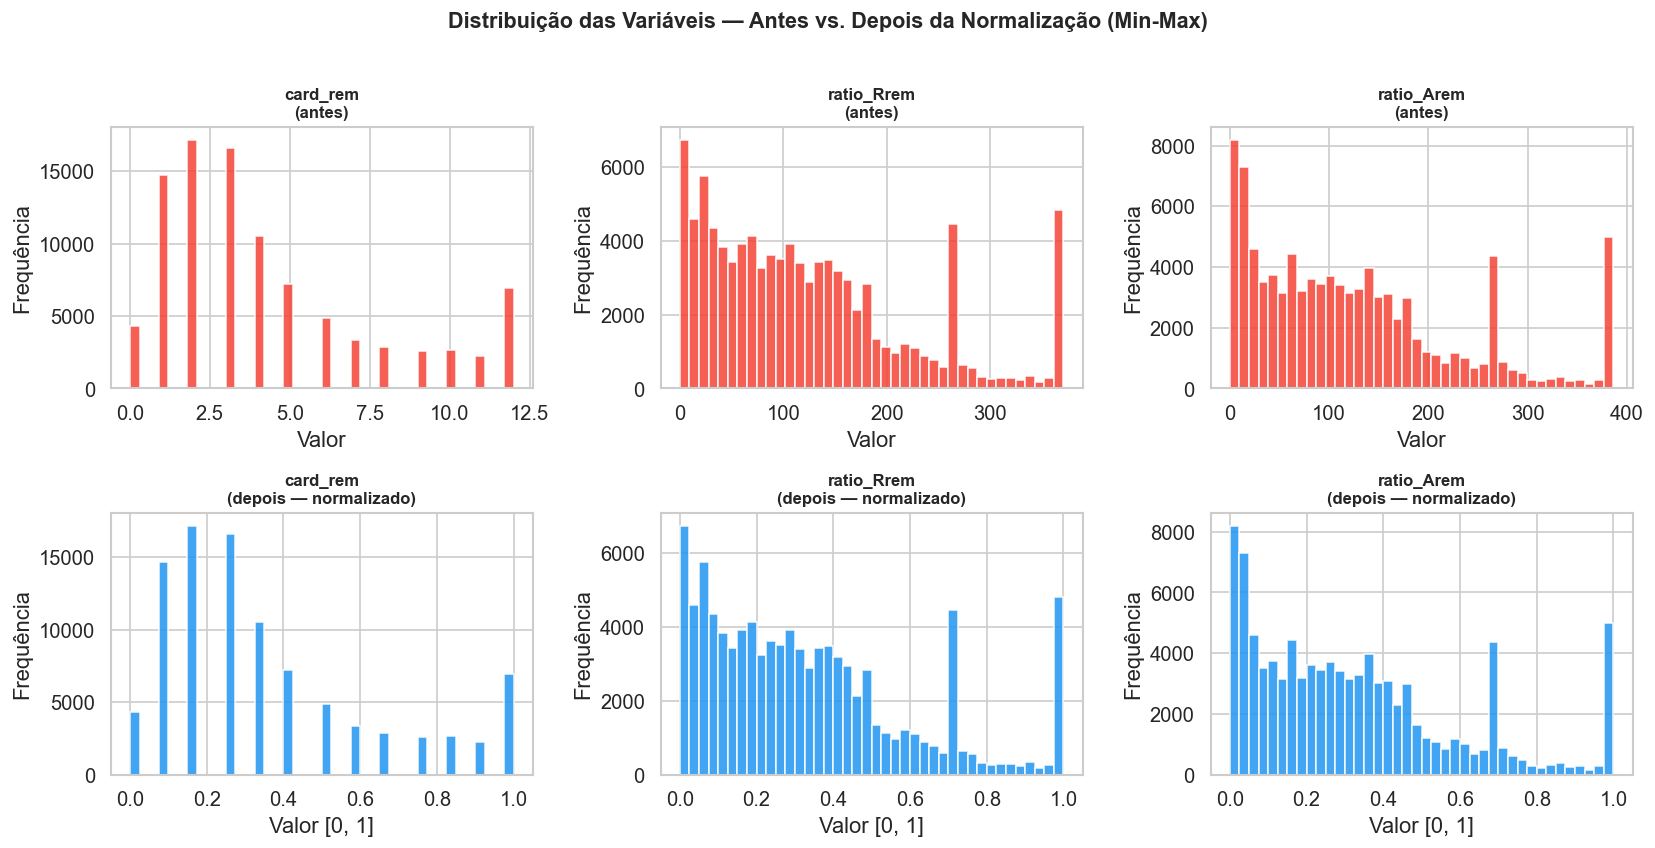

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

COR_ANTES  = '#F44336'
COR_DEPOIS = '#2196F3'

for i, col in enumerate(colunas_normalizar):
    # Antes
    axes[0, i].hist(df[col], bins=40, color=COR_ANTES, edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col}\n(antes)', fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Frequência')
    axes[0, i].set_xlabel('Valor')

    # Depois
    axes[1, i].hist(df_norm[col], bins=40, color=COR_DEPOIS, edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'{col}\n(depois — normalizado)', fontweight='bold', fontsize=10)
    axes[1, i].set_ylabel('Frequência')
    axes[1, i].set_xlabel('Valor [0, 1]')

plt.suptitle('Distribuição das Variáveis — Antes vs. Depois da Normalização (Min-Max)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_normalizacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Exportação

In [9]:
df_norm.to_csv('urldata_normalized.csv', index=False, encoding='utf-8')

print(f'Guardado: urldata_normalized.csv')
print(f'  {len(df_norm):,} linhas x {df_norm.shape[1]} colunas')

Guardado: urldata_normalized.csv
  95,911 linhas x 14 colunas
